In [11]:
import numpy as np
import pandas as pd
import json
from scipy.io import arff

from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

import plotly.graph_objects as go
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [2]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [3]:
def generate_data_set(params):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=params["sample_size"] + 1,
        n_classes=params["label_number"],
        n_labels=params["avg_label_number"],
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [4]:
def resample_data_set(inputs_, outputs_, params):
    sample_size = inputs_.shape[0] - 1
    indices = np.arange(sample_size + 1)
    np.random.shuffle(indices)

    inputs_ = inputs_[indices, :]
    outputs_ = outputs_[indices, :]

    inputs, outputs = (inputs_[:-1, :], outputs_[:-1, :])
    input_test, output_test = (
        inputs_[-1, :].reshape(1, -1),
        outputs_[-1, :].reshape(1, -1),
    )

    inputs_train, inputs_calibration, outputs_train, outputs_calibration = (
        train_test_split(inputs, outputs, test_size=params["cal_size"])
    )

    input_scaler = StandardScaler()
    scaled_inputs_train = input_scaler.fit_transform(inputs_train)
    scaled_inputs_calibration = input_scaler.transform(inputs_calibration)
    scaled_input_test = input_scaler.transform(input_test)

    (
        scaled_inputs_selection,
        scaled_inputs_proper_cal,
        outputs_selection,
        outputs_proper_cal,
    ) = train_test_split(
        scaled_inputs_calibration,
        outputs_calibration,
        test_size=params["proper_cal_size"],
    )

    return (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    )

## FNR risk

In [5]:
def make_FNR_lower_empirical_risk(outputs, probas):
    sample_size = outputs.shape[0]
    def FNR_lower_empirical_risk(order):
        tmp = (
            (np.logical_and(outputs, probas < 1 - order)).sum(axis=1)
            / outputs.sum(axis=1)
        ).sum()
        return (0.0 + tmp) / (sample_size + 1)

    return FNR_lower_empirical_risk

In [6]:
def make_FNR_upper_empirical_risk(outputs, probas):
    sample_size = outputs.shape[0]
    def FNR_upper_empirical_risk(order):
        tmp = (
            (np.logical_and(outputs, probas < 1 - order)).sum(axis=1)
            / outputs.sum(axis=1)
        ).sum()
        return (1.0 + tmp) / (sample_size + 1)

    return FNR_upper_empirical_risk

In [7]:
def make_FNR_empirical_risk(outputs, probas):
    def FNR_empirical_risk(order):
        return (
            (np.logical_and(outputs, probas < 1 - order)).sum(axis=1)
            / outputs.sum(axis=1)
        ).mean()

    return FNR_empirical_risk

## Level search

In [8]:
def dichotomy_search(func, change_points):
    cardinal = change_points.shape[0]
    left_index = 0
    right_index = cardinal - 1

    f_right = func(change_points[right_index])
    f_left = func(change_points[left_index])

    if f_right * f_left > 0:
        if f_left > 0:
            return right_index
        else:
            return left_index

    while (right_index - left_index) >= 2:
        middle_index = max(
            min(np.int64((left_index + right_index) / 2), right_index), left_index
        )
        f_middle = func(change_points[middle_index])

        if (f_middle == 0) or (f_left * f_middle < 0):
            right_index = middle_index
            f_right = f_middle
        else:
            left_index = middle_index
            f_left = f_middle

    if f_left * f_right < 0:
        return right_index
    else:
        return left_index

## Size function

In [9]:
def size_function(probas, order):
    return (probas >= 1 - order).sum(axis=1).mean()

# One repetition of conformal risk-control

In [12]:
arff_file = arff.loadarff("../datasets/yeast.arff")
data_frame = pd.DataFrame(arff_file[0])
inputs_ = (data_frame[data_frame.columns[:103]]).to_numpy()
outputs_ = np.int64((data_frame[data_frame.columns[103:]]).to_numpy() == b"TRUE")

In [31]:
params_global = reader("params/yeast.json")

{'data': {'cal_size': 0.3, 'proper_cal_size': 0.5, 'label_number': 14}, 'predictor': {'log_lam_min': -2, 'log_lam_max': 4, 'lam_base': 10, 'lam_number': 200}, 'risk': {'control_level': 0.1}}


In [14]:
lam_grid = np.logspace(
    params_global["predictor"]["log_lam_min"],
    params_global["predictor"]["log_lam_max"],
    params_global["predictor"]["lam_number"],
)
predictors = [OneVsRestClassifier(LogisticRegression(C=1 / lam)) for lam in lam_grid]

In [15]:
(
    (scaled_inputs_train, outputs_train),
    (scaled_inputs_calibration, outputs_calibration),
    (
        scaled_inputs_selection,
        scaled_inputs_proper_cal,
        outputs_selection,
        outputs_proper_cal,
    ),
    (scaled_input_test, output_test),
) = resample_data_set(inputs_, outputs_, params_global["data"])

In [16]:
for predictor in predictors:
    predictor.fit(scaled_inputs_train, outputs_train)

In [17]:
probas_calibration_per_predictor = [
    predictor.predict_proba(scaled_inputs_calibration) for predictor in predictors
]

probas_selection_per_predictor = [
    predictor.predict_proba(scaled_inputs_selection) for predictor in predictors
]
proba_test_per_predictor = [
    predictor.predict_proba(scaled_input_test) for predictor in predictors
]

## Oracle sizes

In [18]:
def compute_order(
    risk, risk_control_level, change_points
):
    index = dichotomy_search(
        lambda q: (risk(q) - risk_control_level), change_points
    )
    return change_points[index]

In [19]:
oracle_risk_per_predictor = [
    make_FNR_empirical_risk(
        np.concatenate((outputs_calibration, output_test)),
        np.concatenate((probas_calibration, proba_test)),
    )
    for probas_calibration, proba_test in zip(
        probas_calibration_per_predictor, proba_test_per_predictor
    )
]
oracle_change_points_per_predictor = [
    np.concatenate(
        (
            [0.0],
            np.sort(1 - (np.concatenate((probas_calibration, proba_test))).flatten()),
            [1.0],
        )
    )
    for probas_calibration, proba_test in zip(
        probas_calibration_per_predictor, proba_test_per_predictor
    )
]
oracle_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(
        oracle_risk_per_predictor, oracle_change_points_per_predictor
    )
]
oracle_size_per_predictor = [
    size_function(np.concatenate((probas_calibration, proba_test)), order)
    for probas_calibration, proba_test, order in zip(
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        oracle_order_per_predictor,
    )
]

## Upper and lower sizes

In [20]:
lower_risk_per_predictor = [
    make_FNR_lower_empirical_risk(outputs_calibration, probas_calibration)
    for probas_calibration in probas_calibration_per_predictor
]
change_points_per_predictor = [
    np.concatenate(
        (
            [0.0],
            np.sort(1 - probas_calibration.flatten()),
            [1.0],
        )
    )
    for probas_calibration in probas_calibration_per_predictor
]

In [21]:
lower_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(lower_risk_per_predictor, change_points_per_predictor)
]
lower_size_per_predictor = [
    size_function(np.concatenate((probas_calibration, proba_test)), order)
    for probas_calibration, proba_test, order in zip(
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        lower_order_per_predictor,
    )
]

In [22]:
upper_risk_per_predictor = [
    make_FNR_upper_empirical_risk(outputs_calibration, probas_calibration)
    for probas_calibration in probas_calibration_per_predictor
]

In [23]:
upper_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(upper_risk_per_predictor, change_points_per_predictor)
]
upper_size_per_predictor = [
    size_function(np.concatenate((probas_calibration, proba_test)), order)
    for probas_calibration, proba_test, order in zip(
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        upper_order_per_predictor,
    )
]

## Form split

In [24]:
selection_risk_per_predictor = [
    make_FNR_upper_empirical_risk(outputs_selection, probas_selection)
    for probas_selection in probas_selection_per_predictor
]
selection_change_points_per_predictor = [
    np.concatenate(
        (
            [0.0],
            np.sort(1 - probas_selection.flatten()),
            [1.0],
        )
    )
    for probas_selection in probas_selection_per_predictor
]

selection_upper_order_per_predictor = [
    compute_order(
        risk, params_global["risk"]["control_level"], change_points
    )
    for risk, change_points in zip(
        selection_risk_per_predictor, selection_change_points_per_predictor
    )
]

selection_upper_size_per_predictor = [
    size_function(probas_selection, order)
    for probas_selection, order in zip(
        probas_selection_per_predictor, selection_upper_order_per_predictor
    )
]

## Visu

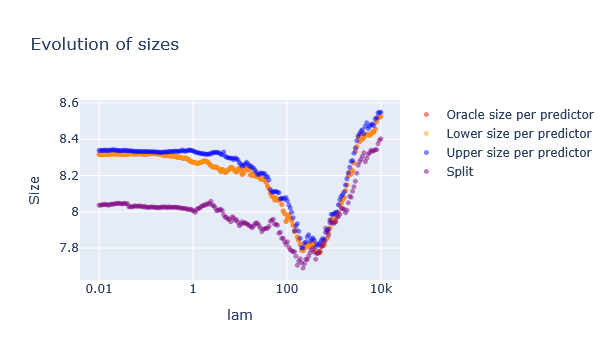

In [25]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=lam_grid,
        y=oracle_size_per_predictor,
        name="Oracle size per predictor",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="red",  # Set the marker color
            opacity=0.5,  # Set the marker opacity
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=lam_grid,
        y=lower_size_per_predictor,
        name="Lower size per predictor",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="orange",  # Set the marker color
            opacity=0.5,  # Set the marker opacity
        ),
    )
)


fig.add_trace(
    go.Scatter(
        x=lam_grid,
        y=upper_size_per_predictor,
        name="Upper size per predictor",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="blue",  # Set the marker color
            opacity=0.5,  # Set the marker opacity
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=lam_grid,
        y=selection_upper_size_per_predictor,
        name="Split",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=5,  # Set the marker size
            color="purple",  # Set the marker color
            opacity=0.5,  # Set the marker opacity
        ),
    )
)

fig.update_layout(
    title="Evolution of sizes",
    xaxis_title="lam",
    yaxis_title="Size",
)
fig.update_xaxes(type="log")
fig.show()

## Oracle prediction set

In [26]:
oracle_predictor_index = np.argmin(oracle_size_per_predictor)
oracle_prediction_set = np.int64(
    proba_test_per_predictor[oracle_predictor_index]
    >= 1 - oracle_order_per_predictor[oracle_predictor_index]
)

In [27]:
oracle_size = oracle_prediction_set.sum(axis=1).item()
oracle_fnr_test = (
    np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
    / output_test.sum(axis=1)
).item()
print("Control level: {}".format(params_global["risk"]["control_level"]))
print("Oracle FNR: {}.".format(oracle_fnr_test))
print("Oracle size: {}.".format(oracle_size))
print("Output size: {}.".format(output_test.sum()))
print(oracle_prediction_set)
print(output_test)

Control level: 0.1
Oracle FNR: 0.0.
Oracle size: 7.
Output size: 4.
[[1 1 0 1 1 1 0 0 0 0 0 1 1 0]]
[[1 1 0 0 0 0 0 0 0 0 0 1 1 0]]


## Upper prediction set

In [28]:
proba_test_per_predictor[0]

array([[7.78798722e-01, 3.60535601e-01, 1.28007070e-02, 1.41841630e-01,
        2.27403543e-01, 2.99582545e-01, 2.11449509e-01, 7.09504376e-02,
        2.00585027e-03, 7.27444959e-02, 3.09989827e-01, 9.53568892e-01,
        9.39787007e-01, 5.63152504e-20]])

In [32]:
min_upper_size = np.min(upper_size_per_predictor)
predictor_index_set = np.arange(lam_grid.shape[0])[
    lower_size_per_predictor <= min_upper_size
]
upper_prediction_set = np.int64(
    [
        np.min(
            [
                size_function(
                    np.concatenate(
                        (
                            probas_calibration_per_predictor[predictor_index],
                            proba_test_per_predictor[predictor_index],
                        )
                    ),
                    1 - proba_test_per_predictor[predictor_index][0, k],
                )
                for predictor_index in predictor_index_set
            ]
        )
        <= min_upper_size
        for k in range(params_global["data"]["label_number"])
    ]
).reshape(1, -1)

In [33]:
upper_size = upper_prediction_set.sum(axis=1).item()
upper_fnr_test = (
    np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
    / output_test.sum(axis=1)
).item()
print("Control level: {}".format(params_global["risk"]["control_level"]))
print("Upper FNR: {}.".format(upper_fnr_test))
print("Upper size: {}.".format(upper_size))
print("Output size: {}.".format(output_test.sum()))
print(upper_prediction_set)
print(output_test)

Control level: 0.1
Upper FNR: 0.0.
Upper size: 7.
Output size: 4.
[[1 1 0 1 1 1 0 0 0 0 0 1 1 0]]
[[1 1 0 0 0 0 0 0 0 0 0 1 1 0]]


## Prediction set from split

In [34]:
split_predictor_index = np.argmin(selection_upper_size_per_predictor)

probas_proper_cal = predictors[split_predictor_index].predict_proba(
    scaled_inputs_proper_cal
)

proper_cal_upper_risk = make_FNR_upper_empirical_risk(
    outputs_proper_cal, probas_proper_cal
)

proper_cal_change_points = np.concatenate(
    (
        [0.0],
        np.sort(1 - probas_proper_cal.flatten()),
        [1.0],
    )
)

proper_cal_upper_order = compute_order(
    proper_cal_upper_risk, params_global["risk"]["control_level"],
    proper_cal_change_points
)
split_prediction_set = np.int64(
    proba_test_per_predictor[split_predictor_index] >= 1 - proper_cal_upper_order
)

In [36]:
split_size = split_prediction_set.sum(axis=1).item()
split_fnr_test = (
    np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
    / output_test.sum(axis=1)
).item()
print("Control level: {}".format(params_global["risk"]["control_level"]))
print("Split FNR: {}.".format(split_fnr_test))
print("Split size: {}.".format(split_size))
print("Output size: {}.".format(output_test.sum()))
print(split_prediction_set)
print(output_test)

Control level: 0.1
Split FNR: 0.0.
Split size: 8.
Output size: 4.
[[1 1 0 1 1 1 0 0 0 0 1 1 1 0]]
[[1 1 0 0 0 0 0 0 0 0 0 1 1 0]]


# Multiple repetitions of conformal risk-control

In [37]:
def compute_oracle_prediction_set(
    outputs_calibration,
    probas_calibration_per_predictor,
    output_test,
    proba_test_per_predictor,
    risk_control_level,
):
    oracle_risk_per_predictor = [
        make_FNR_empirical_risk(
            np.concatenate((outputs_calibration, output_test)),
            np.concatenate((probas_calibration, proba_test)),
        )
        for probas_calibration, proba_test in zip(
            probas_calibration_per_predictor, proba_test_per_predictor
        )
    ]
    oracle_change_points_per_predictor = [
        np.concatenate(
            (
                [0.0],
                np.sort(1 - (np.concatenate((probas_calibration, proba_test))).flatten()),
                [1.0],
            )
        )
        for probas_calibration, proba_test in zip(
            probas_calibration_per_predictor, proba_test_per_predictor
        )
    ]
    oracle_order_per_predictor = [
        compute_order(
            risk, risk_control_level, change_points
        )
        for risk, change_points in zip(
            oracle_risk_per_predictor, oracle_change_points_per_predictor
        )
    ]
    oracle_size_per_predictor = [
        size_function(np.concatenate((probas_calibration, proba_test)), order)
        for probas_calibration, proba_test, order in zip(
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            oracle_order_per_predictor,
        )
    ]

    oracle_predictor_index = np.argmin(oracle_size_per_predictor)
    oracle_prediction_set = np.int64(
        proba_test_per_predictor[oracle_predictor_index]
        >= 1 - oracle_order_per_predictor[oracle_predictor_index]
    )
    return oracle_prediction_set

In [38]:
def compute_upper_prediction_set(
    outputs_calibration,
    probas_calibration_per_predictor,
    proba_test_per_predictor,
    risk_control_level,
):
    change_points_per_predictor = [
        np.concatenate(
            (
                [0.0],
                np.sort(1 - probas_calibration.flatten()),
                [1.0],
            )
        )
        for probas_calibration in probas_calibration_per_predictor
    ]
 
    lower_risk_per_predictor = [
        make_FNR_lower_empirical_risk(outputs_calibration, probas_calibration)
        for probas_calibration in probas_calibration_per_predictor
    ]
    lower_order_per_predictor = [
        compute_order(
            risk, params_global["risk"]["control_level"], change_points
        )
        for risk, change_points in zip(lower_risk_per_predictor, change_points_per_predictor)
    ]
    lower_size_per_predictor = [
        size_function(np.concatenate((probas_calibration, proba_test)), order)
        for probas_calibration, proba_test, order in zip(
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            lower_order_per_predictor,
        )
    ]

    upper_risk_per_predictor = [
        make_FNR_upper_empirical_risk(outputs_calibration, probas_calibration)
        for probas_calibration in probas_calibration_per_predictor
    ]
    upper_order_per_predictor = [
        compute_order(
            risk, params_global["risk"]["control_level"], change_points
        )
        for risk, change_points in zip(upper_risk_per_predictor, change_points_per_predictor)
    ]
    upper_size_per_predictor = [
        size_function(np.concatenate((probas_calibration, proba_test)), order)
        for probas_calibration, proba_test, order in zip(
            probas_calibration_per_predictor,
            proba_test_per_predictor,
            upper_order_per_predictor,
        )
    ]

    min_upper_size = np.min(upper_size_per_predictor)
    predictor_index_set = np.arange(lam_grid.shape[0])[
        lower_size_per_predictor <= min_upper_size
    ]
    upper_prediction_set = np.int64(
        [
            np.min(
                [
                    size_function(
                        np.concatenate(
                            (
                                probas_calibration_per_predictor[predictor_index],
                                proba_test_per_predictor[predictor_index],
                            )
                        ),
                        1 - proba_test_per_predictor[predictor_index][0, k],
                    )
                    for predictor_index in predictor_index_set
                ]
            )
            <= min_upper_size
            for k in range(params_global["data"]["label_number"])
        ]
    ).reshape(1, -1)

    return upper_prediction_set

In [39]:
def select_predictor_index(outputs_selection, probas_selection_per_predictor, risk_control_level):
    selection_change_points_per_predictor = [
        np.concatenate(
            (
                [0.0],
                np.sort(1 - probas_selection.flatten()),
                [1.0],
            )
        )
        for probas_selection in probas_selection_per_predictor
    ]

    selection_risk_per_predictor = [
        make_FNR_upper_empirical_risk(outputs_selection, probas_selection)
        for probas_selection in probas_selection_per_predictor
    ]
    selection_upper_order_per_predictor = [
        compute_order(
            risk, params_global["risk"]["control_level"], change_points
        )
        for risk, change_points in zip(
            selection_risk_per_predictor, selection_change_points_per_predictor
        )
    ]
    selection_upper_size_per_predictor = [
        size_function(probas_selection, order)
        for probas_selection, order in zip(
            probas_selection_per_predictor, selection_upper_order_per_predictor
        )
    ]

    predictor_index = np.argmin(selection_upper_size_per_predictor)
    return predictor_index

In [40]:
def compute_prediction_set(
    predictor, inputs_calibration, output_calibrations, input_test, risk_control_level
):
    probas_calibration = predictor.predict_proba(inputs_calibration)
    change_points = np.concatenate(
        (
            [0.0],
            np.sort(1 - probas_calibration.flatten()),
            [1.0],
        )
    )
    
    upper_risk = make_FNR_upper_empirical_risk(output_calibrations, probas_calibration)
    upper_order = compute_order(
        upper_risk, risk_control_level, change_points
    )

    proba_test = predictor.predict_proba(input_test)
    prediction_set = np.int64(proba_test >= 1 - upper_order)

    return prediction_set

In [41]:
lam_grid = np.logspace(
    params_global["predictor"]["log_lam_min"],
    params_global["predictor"]["log_lam_max"],
    params_global["predictor"]["lam_number"],
)
predictors = [OneVsRestClassifier(LogisticRegression(C=1 / lam)) for lam in lam_grid]

rep_number = 100

In [42]:
results = {
    "size":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
        "Output":[],
    }, "FNR":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
    }
}

In [44]:
for rep_index in tqdm(range(rep_number)):

    (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    ) = resample_data_set(inputs_, outputs_, params_global["data"])


    for predictor in predictors:
        predictor.fit(scaled_inputs_train, outputs_train)


    probas_calibration_per_predictor = [
        predictor.predict_proba(scaled_inputs_calibration) for predictor in predictors
    ]
    proba_test_per_predictor = [
        predictor.predict_proba(scaled_input_test) for predictor in predictors
    ]
    oracle_prediction_set = compute_oracle_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        output_test,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )

    
    upper_prediction_set = compute_upper_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )



    probas_selection_per_predictor = [
        predictor.predict_proba(scaled_inputs_selection) for predictor in predictors
    ]
    split_predictor_index = select_predictor_index(
        outputs_selection, probas_selection_per_predictor, params_global["risk"]["control_level"]
    )
    split_prediction_set = compute_prediction_set(
        predictors[split_predictor_index], scaled_inputs_proper_cal,
        outputs_proper_cal, scaled_input_test, params_global["risk"]["control_level"]
    )

    oracle_fnr = (
        np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    upper_fnr = (
        np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    split_fnr = (
        np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    
    results["FNR"]["Oracle"].append(oracle_fnr)
    results["FNR"]["Upper"].append(upper_fnr)
    results["FNR"]["Split"].append(split_fnr)

    results["size"]["Oracle"].append(oracle_prediction_set.sum())
    results["size"]["Upper"].append(upper_prediction_set.sum())
    results["size"]["Split"].append(split_prediction_set.sum())
    results["size"]["Output"].append(output_test.sum())



100%|██████████| 100/100 [59:07<00:00, 35.48s/it]


In [51]:
print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))
print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
print("Average output size: {}".format(np.mean(results["size"]["Output"])))

Average oracle prediction-set size: 8.5
Average upper prediction-set size: 8.87
Average split prediction-set size: 8.65
Average output size: 4.22


In [52]:
df_volume = pd.DataFrame.from_dict(
    results["size"]
)

(0.0, 14.0)

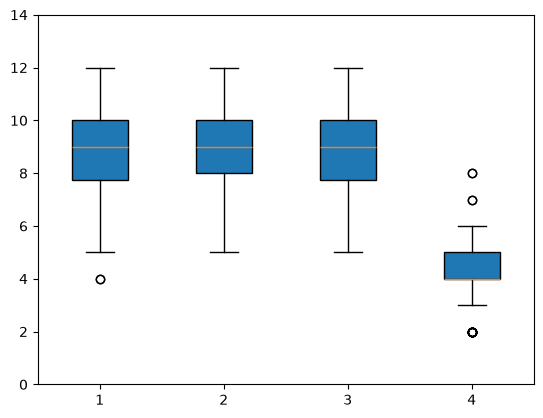

In [58]:
fig, ax = plt.subplots()
box = ax.boxplot(df_volume, patch_artist=True)
ax.set_ylim(0, 14)

In [57]:
print("Average oracle prediction-set FNR: {}".format(np.mean(results["FNR"]["Oracle"])))
print("Average upper prediction-set FNR: {}".format(np.mean(results["FNR"]["Upper"])))
print("Average split prediction-set FNR: {}".format(np.mean(results["FNR"]["Split"])))

Average oracle prediction-set FNR: 0.09428571428571429
Average upper prediction-set FNR: 0.08678571428571429
Average split prediction-set FNR: 0.0925357142857143


In [55]:
df_fnr = pd.DataFrame.from_dict(
    results["FNR"]
)

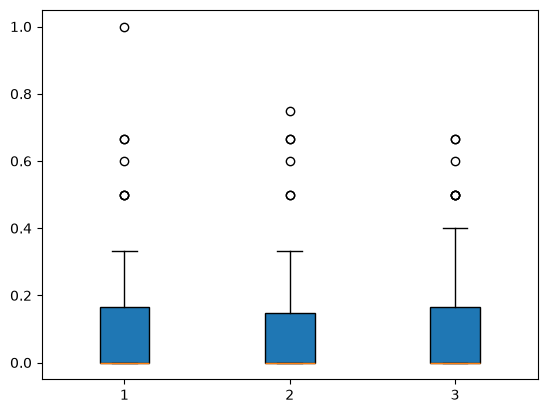

In [56]:
fig, ax = plt.subplots()
box = ax.boxplot(df_fnr, patch_artist=True)